# Music & Mental Health — Predictor de Ansiedad

**Descripción del proyecto**
- Buscar y comprender un dataset nuevo.
- Modelar los datos utilizando un algoritmo de Machine Learning, Deep Learning o NLP.
- Analizar los resultados y optimizar el modelo.
- Integrarlo en Render usando una aplicación basada en Flask.


**Dataset: Music & Mental Health Survey (MxMH)**

El dataset proviene de una encuesta pública disponible en Kaggle, realizada 
por Catherine Rasgaitis. Recoge información sobre los hábitos musicales de 
736 personas y su estado de salud mental autoreportado.

**Objetivo**

Construir un modelo que sea capaz de predecir si una persona tiene un **nivel de ansiedad alto o bajo** en función de sus hábitos musicales.

**Estructura del proyecto**

1. **EDA** — Análisis exploratorio del dataset (`explore.ipynb`)
2. **Modelado** — Preprocesamiento, entrenamiento y evaluación (`model.ipynb`)
3. **Despliegue** — Aplicación web con Flask, desplegada en Render

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import GridSearchCV


import joblib

import warnings
warnings.filterwarnings('ignore')

## Paso 1: Busca un conjunto de datos


In [2]:
df = pd.read_csv("../data/raw/mxmh_survey_results.csv")
df.head()

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


# EDA 
1. Analisis univariante
    - variables categoricas
    - Variables numéricas
2. Analisis multivariante
    - correlaciones (heatmap)
3. Outliers


In [3]:
df.shape

(736, 33)

In [4]:
df.isnull().sum()

Timestamp                         0
Age                               1
Primary streaming service         1
Hours per day                     0
While working                     3
Instrumentalist                   4
Composer                          1
Fav genre                         0
Exploratory                       0
Foreign languages                 4
BPM                             107
Frequency [Classical]             0
Frequency [Country]               0
Frequency [EDM]                   0
Frequency [Folk]                  0
Frequency [Gospel]                0
Frequency [Hip hop]               0
Frequency [Jazz]                  0
Frequency [K pop]                 0
Frequency [Latin]                 0
Frequency [Lofi]                  0
Frequency [Metal]                 0
Frequency [Pop]                   0
Frequency [R&B]                   0
Frequency [Rap]                   0
Frequency [Rock]                  0
Frequency [Video game music]      0
Anxiety                     

In [5]:
df["BPM"].value_counts()

BPM
120.0    45
140.0    25
150.0    18
110.0    16
105.0    15
         ..
68.0      1
624.0     1
218.0     1
186.0     1
168.0     1
Name: count, Length: 135, dtype: int64

In [6]:
df.dropna(inplace=True)
df.shape

(616, 33)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['Timestamp', 'Age', 'Primary streaming service', 'Hours per day',
       'While working', 'Instrumentalist', 'Composer', 'Fav genre',
       'Exploratory', 'Foreign languages', 'BPM', 'Frequency [Classical]',
       'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]',
       'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]',
       'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]',
       'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]',
       'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]',
       'Anxiety', 'Depression', 'Insomnia', 'OCD', 'Music effects',
       'Permissions'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 616 entries, 2 to 735
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     616 non-null    str    
 1   Age                           616 non-null    float64
 2   Primary streaming service     616 non-null    str    
 3   Hours per day                 616 non-null    float64
 4   While working                 616 non-null    str    
 5   Instrumentalist               616 non-null    str    
 6   Composer                      616 non-null    str    
 7   Fav genre                     616 non-null    str    
 8   Exploratory                   616 non-null    str    
 9   Foreign languages             616 non-null    str    
 10  BPM                           616 non-null    float64
 11  Frequency [Classical]         616 non-null    str    
 12  Frequency [Country]           616 non-null    str    
 13  Frequency [EDM]      

In [10]:
df["Fav genre"].value_counts()

Fav genre
Rock                149
Pop                  97
Metal                77
Classical            38
Video game music     36
EDM                  36
Hip hop              32
R&B                  30
Folk                 25
K pop                21
Country              20
Rap                  20
Jazz                 19
Lofi                 10
Gospel                4
Latin                 2
Name: count, dtype: int64

In [11]:
df["Timestamp"].value_counts()

Timestamp
8/27/2022 21:28:18     1
8/27/2022 21:40:40     1
8/27/2022 21:54:47     1
8/27/2022 21:56:50     1
8/27/2022 22:00:29     1
                      ..
10/30/2022 14:37:28    1
11/1/2022 22:26:42     1
11/3/2022 23:24:38     1
11/4/2022 17:31:47     1
11/9/2022 1:55:20      1
Name: count, Length: 616, dtype: int64

Eliminamos: `Permissions`, `Timestamp` y `BPM`
- Permissions: no aporta información relevante para el análisis y modelado, ya que es una variable de control que se utilizó para verificar que los encuestados leyeran las instrucciones antes de completar la encuesta.
- Timestamp: identificador sin valor predictivo
- BPM: Tiene bastante ruido (la gente no sabe exactamente el BPM de su canción favorita)

In [12]:
df_clean = df.drop(['Timestamp', 'BPM', 'Permissions'], axis=1)
df_clean.head()

,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,Frequency [Classical],...,Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects
2,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,Never,...,Rarely,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect
3,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,Sometimes,...,Sometimes,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve
4,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,Never,...,Sometimes,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve
5,18.0,Spotify,5.0,Yes,Yes,Yes,Jazz,Yes,Yes,Rarely,...,Very frequently,Very frequently,Very frequently,Very frequently,Never,8.0,8.0,7.0,7.0,Improve
6,18.0,YouTube Music,3.0,Yes,Yes,No,Video game music,Yes,Yes,Sometimes,...,Rarely,Rarely,Never,Never,Sometimes,4.0,8.0,6.0,0.0,Improve


In [13]:
df.select_dtypes(include=["object"]).columns

Index(['Timestamp', 'Primary streaming service', 'While working',
       'Instrumentalist', 'Composer', 'Fav genre', 'Exploratory',
       'Foreign languages', 'Frequency [Classical]', 'Frequency [Country]',
       'Frequency [EDM]', 'Frequency [Folk]', 'Frequency [Gospel]',
       'Frequency [Hip hop]', 'Frequency [Jazz]', 'Frequency [K pop]',
       'Frequency [Latin]', 'Frequency [Lofi]', 'Frequency [Metal]',
       'Frequency [Pop]', 'Frequency [R&B]', 'Frequency [Rap]',
       'Frequency [Rock]', 'Frequency [Video game music]', 'Music effects',
       'Permissions'],
      dtype='str')

`Timestamp` no tiene sentido representarlo en un gráfico aunq lo considere categórico porque son datos todos distintos entre si. 

In [ ]:
var_cat = df_clean.select_dtypes(include=["object"]).columns
var_cat

Index(['Primary streaming service', 'While working', 'Instrumentalist',
       'Composer', 'Fav genre', 'Exploratory', 'Foreign languages',
       'Frequency [Classical]', 'Frequency [Country]', 'Frequency [EDM]',
       'Frequency [Folk]', 'Frequency [Gospel]', 'Frequency [Hip hop]',
       'Frequency [Jazz]', 'Frequency [K pop]', 'Frequency [Latin]',
       'Frequency [Lofi]', 'Frequency [Metal]', 'Frequency [Pop]',
       'Frequency [R&B]', 'Frequency [Rap]', 'Frequency [Rock]',
       'Frequency [Video game music]', 'Music effects'],
      dtype='str')

Creamos un grupo con todas las frecuencias, porque ya hay una 

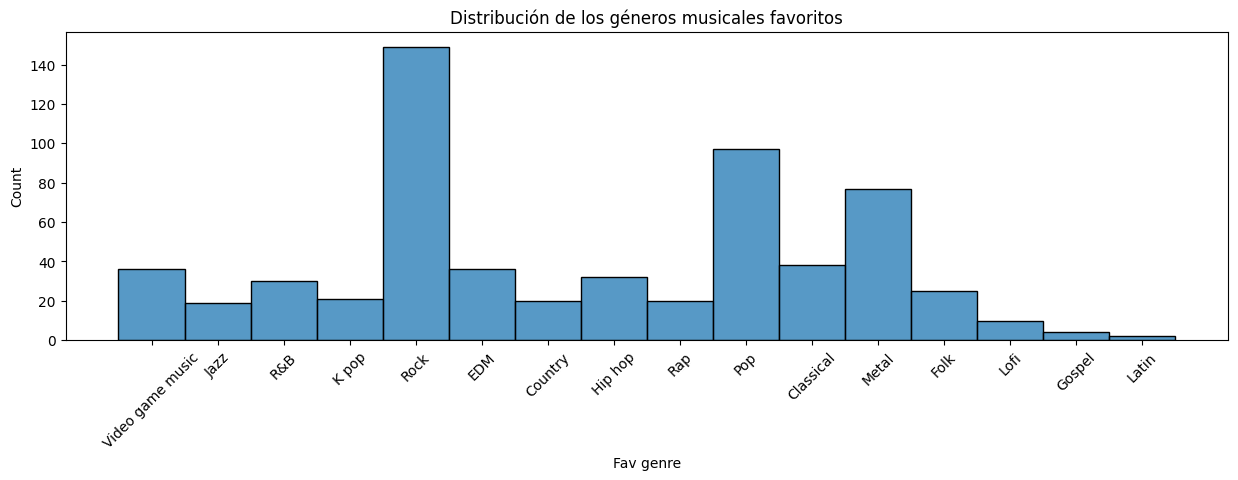

In [15]:
#analisis univariante de las frecuencias de cada genero musical
plt.figure(figsize=(15,4))

sns.histplot(x="Fav genre", data=df_clean)
plt.xticks(rotation=45)

plt.title("Distribución de los géneros musicales favoritos")
plt.show()


Rock, Pop y Metal lideran como géneros favoritos. Esto es relevante para nuestro modelo: géneros como Gospel y LoFi tienen muy pocos representantes, lo que puede afectar la capacidad del modelo para generalizar sobre ellos.

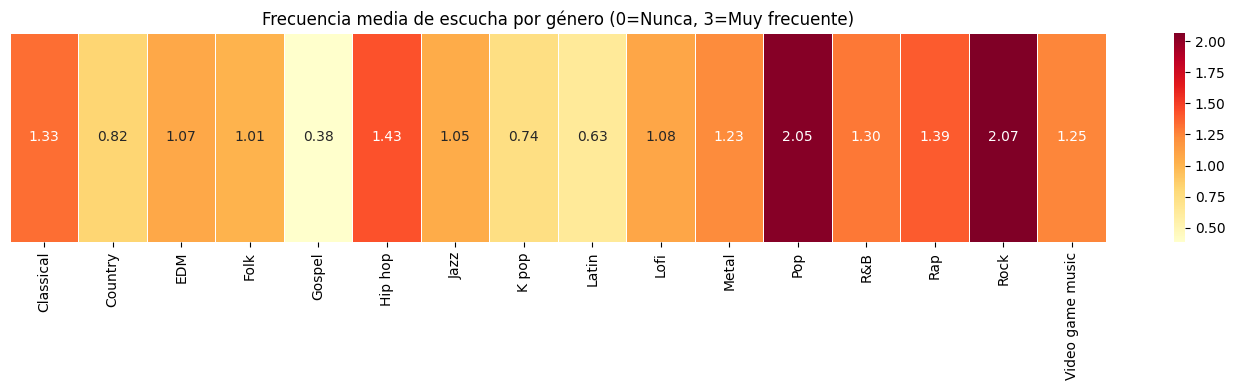

In [16]:
freq_map = {"Never": 0, "Rarely": 1, "Sometimes": 2, "Very frequently": 3}
freq_cols = [c for c in df_clean.columns if "Frequency" in c]

# Forzar la conversión con map() en lugar de replace()
df_freq = df_clean[freq_cols].apply(lambda col: col.map(freq_map))

plt.figure(figsize=(14, 4))
sns.heatmap(
    df_freq.mean().values.reshape(1, -1),
    xticklabels=[c[11:-1] for c in freq_cols],
    annot=True, fmt=".2f", cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Frecuencia media de escucha por género (0=Nunca, 3=Muy frecuente)")
plt.yticks([])
plt.tight_layout()
plt.show()

Rock (2.07) y Pop (2.05) son los géneros escuchados con mayor frecuencia,
seguidos de Hip hop (1.43) y Rap (1.39). En el extremo opuesto, Gospel (0.38) y Latin (0.63) son los géneros que menos se escuchan en promedio.

Esto es consistente con el gráfico de géneros favoritos que hemos hecho antes: los géneros más populares como favorito son también los que más se escuchan en el día a día.

Generos con frecuencia media muy baja (Gospel, Latin, K-pop) tienen poca representación en el dataset, lo que puede dificultar que el modelo aprenda patrones asociados a ellos.

In [17]:
#analisis univariante de el resto de las variables categoricas
var_cat = df_clean.drop(["Fav genre",'Frequency [Classical]',
 'Frequency [Country]',
 'Frequency [EDM]',
 'Frequency [Folk]',
 'Frequency [Gospel]',
 'Frequency [Hip hop]',
 'Frequency [Jazz]',
 'Frequency [K pop]',
 'Frequency [Latin]',
 'Frequency [Lofi]',
 'Frequency [Metal]',
 'Frequency [Pop]',
 'Frequency [R&B]',
 'Frequency [Rap]',
 'Frequency [Rock]',
 'Frequency [Video game music]'], axis=1).select_dtypes(include=["object"])


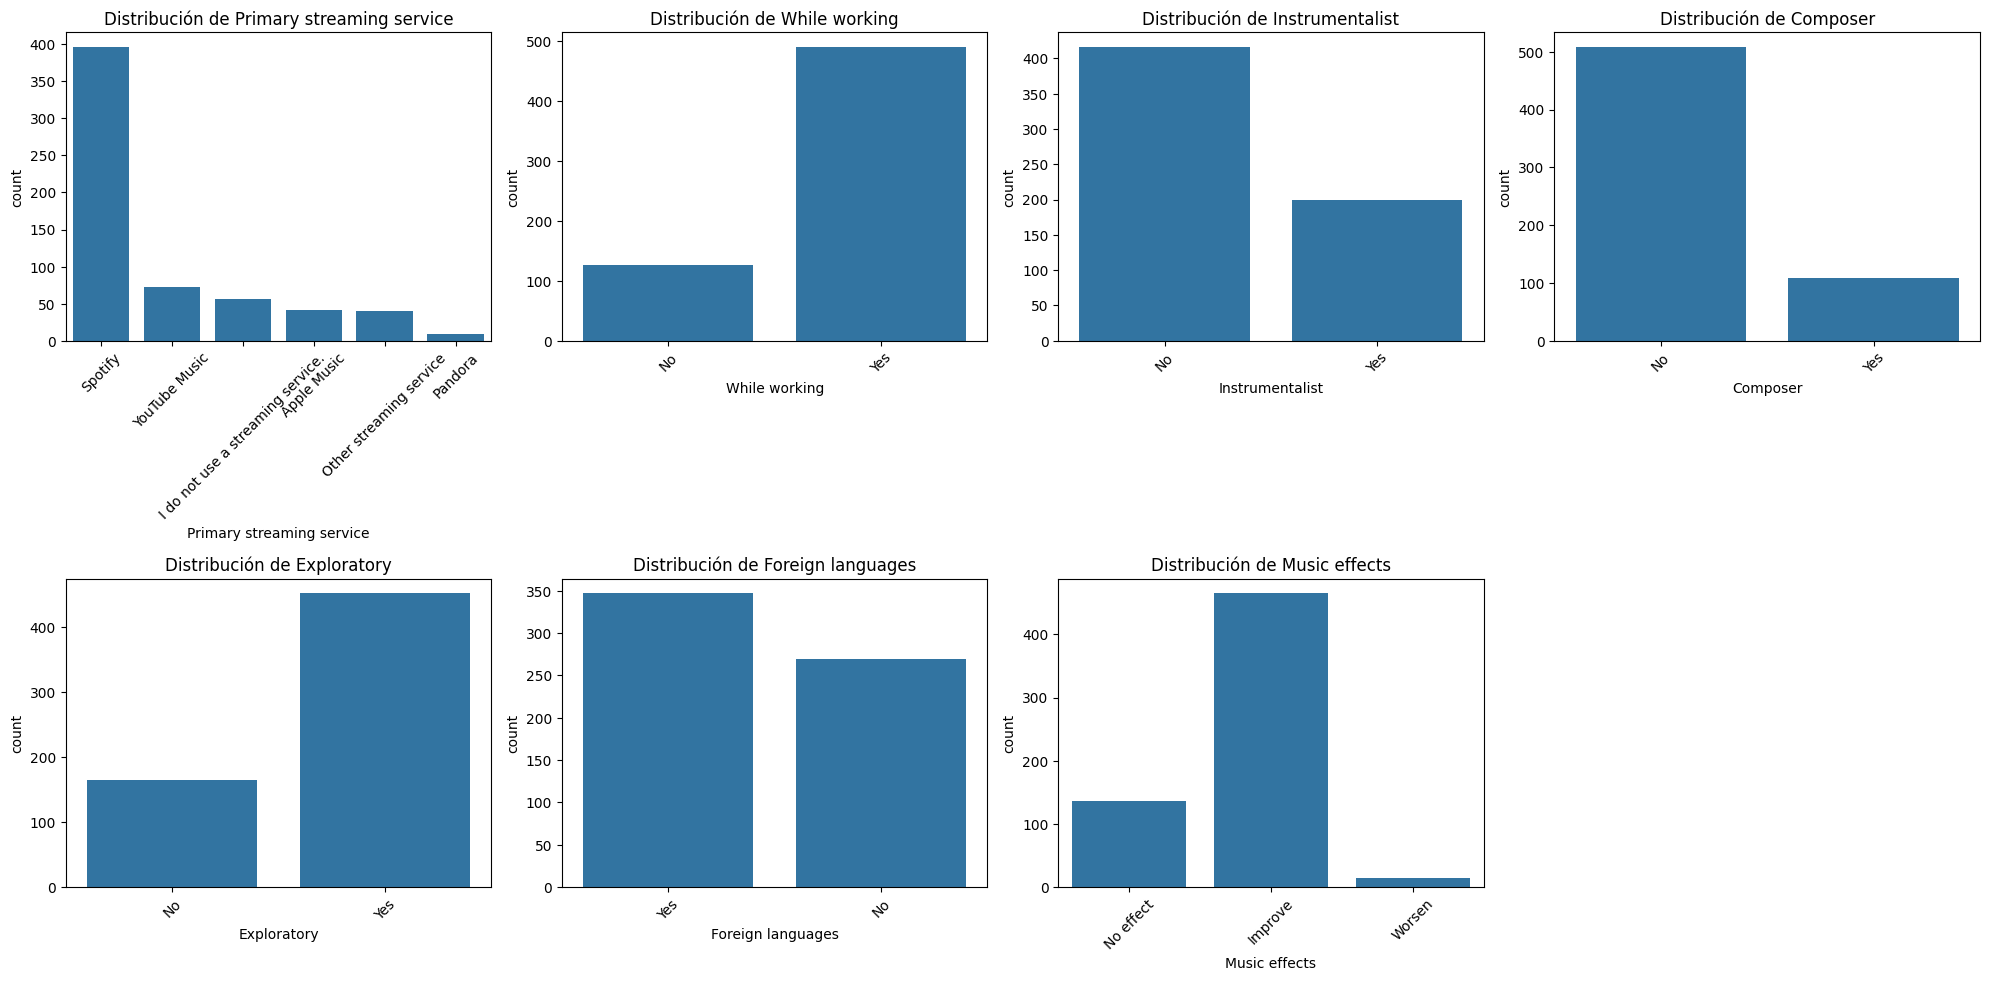

In [18]:
plt.figure(figsize=(20,20))

for i, col in enumerate(var_cat):
    plt.subplot(4,4,i+1)
    sns.countplot(x=col, data=df_clean)
    plt.xticks(rotation=45)
    plt.title(f"Distribución de {col}")
    
plt.tight_layout()
plt.show()


En estas distribuciones podemos ver:
- Spotify es la plataforma más usada con diferencia
- Casi el 80% de las personas escucha musica mientras trabajan
- La mayoria no escucha música instrumental
- No hay gran diferencia entre los que si escuchan en idiomas extranjeros y los que no. Pero predominan los primeros. 
- En cuanto a los efectos de la musica: la gran mayoria siente que les mejora, siendo muy pocos lo que sienten lo contrario. Hay una pequeña cantidad que no siente ningún efecto
- La variable `Composer` nos indica si el encuestado compone música o no: vemos que la gran mayoria no lo hace

**variables numéricas**

In [19]:
var_num = df_clean.select_dtypes(include=["int64", "float64"]).columns

Comparamos las 4 variables de salud mental: "Anxiety", "Depression", "Insomnia", "OCD"

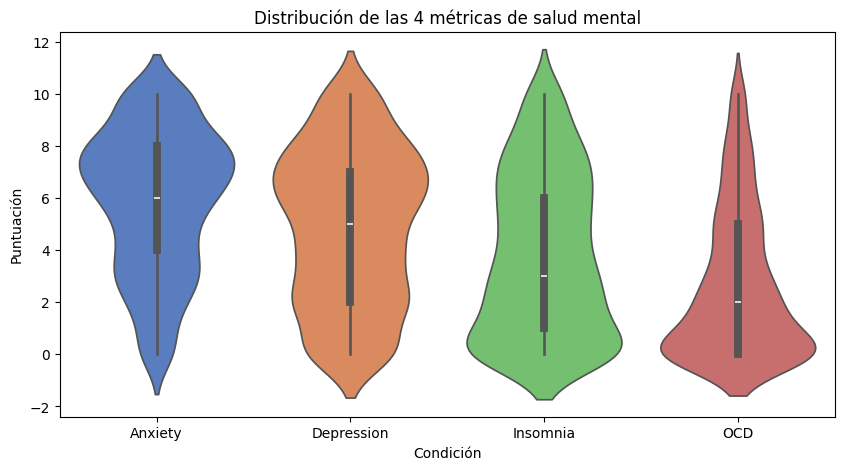

In [20]:
health_vars = ["Anxiety", "Depression", "Insomnia", "OCD"]
df_melt = df_clean[health_vars].melt(var_name="Condición", value_name="Puntuación")

plt.figure(figsize=(10, 5))
sns.violinplot(x="Condición", y="Puntuación", data=df_melt, palette="muted")
plt.title("Distribución de las 4 métricas de salud mental")
plt.show()

En este violinplot de las variables de salud mental podemos analizar que:
- La Ansiedad es la condición más prevalente en los encuestados:
su mediana (~6/10) es la más alta y su distribución está claramente 
concentrada en valores altos.

- La Depresión sigue un patrón parecido pero algo más moderado.

- El Insomnio y especialmente el OCD tienen distribuciones muy asimétricas 
(sesgadas hacia la izquierda): la mayoría de personas reporta valores 
bajos o nulos, pero existe una "cola" de casos severos.

Esto justifica elegir **Anxiety como variable target** del modelo: 
es la condición con mayor variabilidad y representación en el dataset, 
lo que dará más información al algoritmo para aprender patrones.

In [21]:
var_num = var_num.drop(['Anxiety', 'Depression', 'Insomnia', 'OCD']) #representamos el resto de variables numéricas que no son de salud para ver su distribución

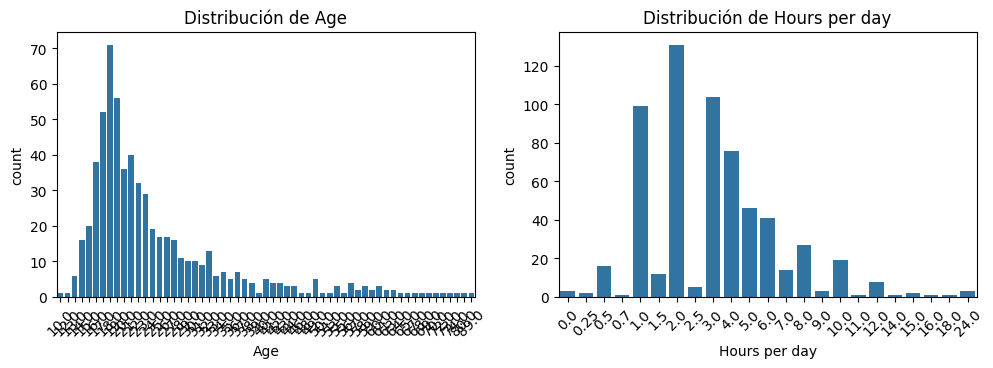

In [22]:
plt.figure(figsize=(20,10))

for i, col in enumerate(var_num):
    plt.subplot(3,4,i+1)
    sns.countplot(x=col, data=df_clean)
    plt.xticks(rotation=45)
    plt.title(f"Distribución de {col}")
    
plt.tight_layout()
plt.show()

`Edad` aunque hay datos demasiado variables, podemos ver una asimetría positiva (sesgada a la derecha), con la mayor concentración de personas en edades jóvenes y menos personas a medida que aumenta la edad.

En cuanto al `número de horas al dia`, vemos que predominan las horas intermedias: entre 1h y 4h es el tiempo más frecuente. Bastante coherente con la realidad 

**Análisis multivariado**

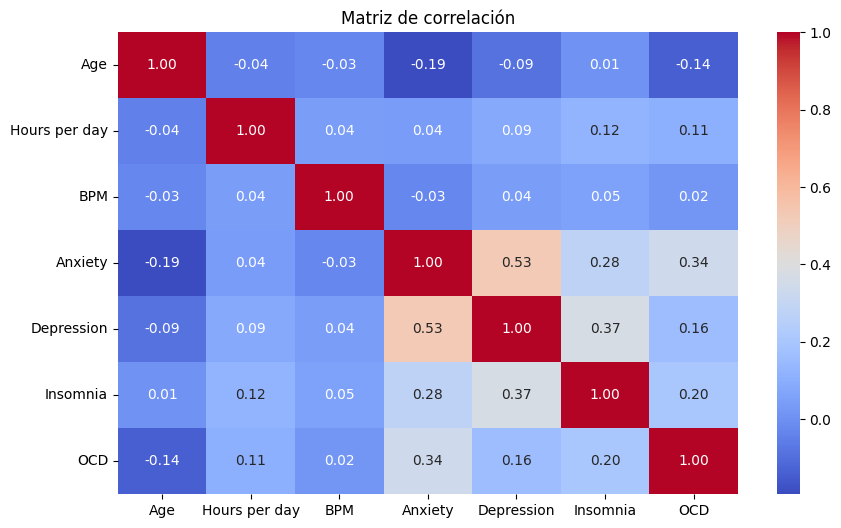

In [23]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

## Conclusiones del análisis de correlación

**Entre variables de salud mental:**
- Ansiedad y Depresión tienen la correlación más alta (0.37 aprox.), 
  lo que tiene sentido clínicamente: ambos trastornos suelen coexistir.
- OCD e Insomnio también correlacionan con Ansiedad y Depresión, 
  sugiriendo que quienes tienen un trastorno tienden a tener otros.

**Horas de escucha y salud mental:**
- Las correlaciones positivas entre "Hours per day" e Insomnio/OCD (0.11-0.12) 
  podrían indicar que personas con estos trastornos usan la música como 
  herramienta de escape o regulación emocional.
- OJO: correlación ≠ causalidad. No sabemos si la música causa el trastorno 
  o si las personas con trastornos escuchan más música.

**La edad casi no correlaciona con nada** (valores ≈ 0), 
lo que sugiere que la relación entre música y salud mental 
es transversal a todas las edades del dataset.

Ahora es interesante ver cómo se relacionan el tipo de género favorito con las distintas variables relacionadas con la salud.

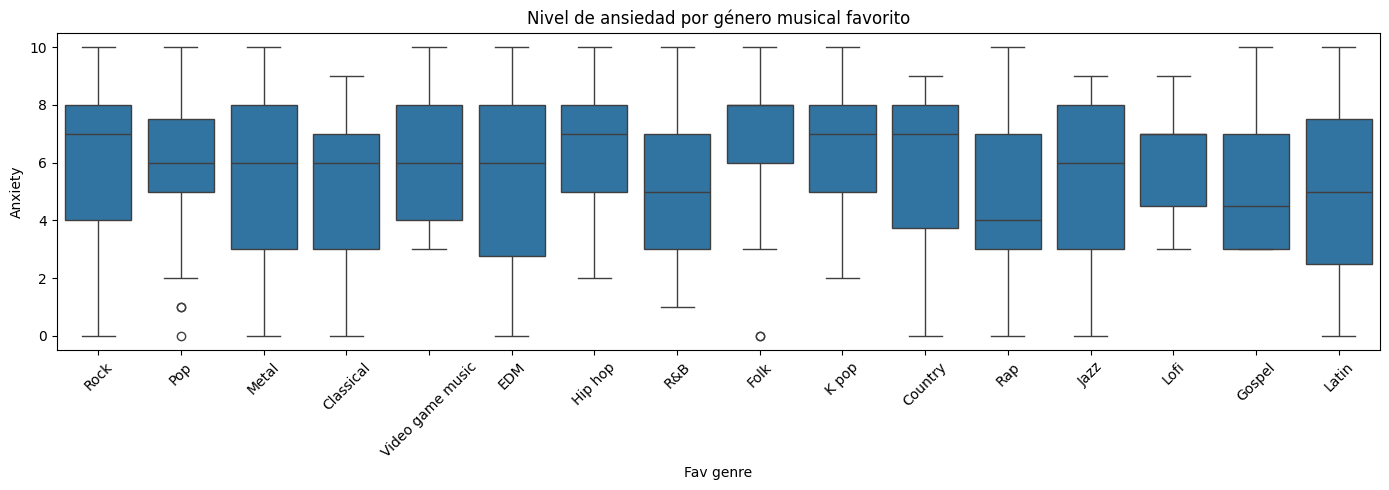

In [24]:
plt.figure(figsize=(14, 5))
sns.boxplot(x="Fav genre", y="Anxiety", data=df_clean, 
            order=df_clean["Fav genre"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Nivel de ansiedad por género musical favorito")
plt.tight_layout()
plt.show()

En términos generales, el nivel de ansiedad es alto en todos los géneros (medianas entre 5 y 7), lo que sugiere que la ansiedad es una condición
transversal independientemente del gusto musical.

Sin embargo, hay algunas diferencias notables:
- **Metal, Rock y EDM** tienen medianas altas (~7) y cajas amplias, indicando tanto alta ansiedad media como mucha variabilidad entre oyentes.
- **Latin y R&B** muestran medianas más bajas (~5), sugiriendo que sus oyentes tienden a reportar menos ansiedad.
- **Pop** es el único género con outliers en 0, es decir, hay oyentes de Pop con ansiedad nula, lo que no aparece en otros géneros.

La amplia dispersión en casi todos los géneros indica que el género favorito por sí solo no es un predictor suficiente de ansiedad: el modelo necesitará combinar varias variables para hacer predicciones fiables.

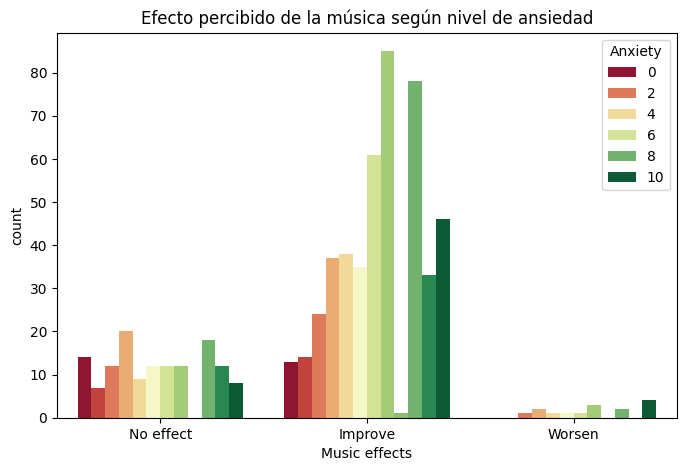

In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Music effects", hue="Anxiety", 
              data=df_clean, palette="RdYlGn")
plt.title("Efecto percibido de la música según nivel de ansiedad")
plt.show()

¿La música mejora, empeora o no afecta la ansiedad?

La categoría "Improve" (mejora) domina en todos los niveles de ansiedad, lo que indica que la mayoría de los encuestados percibe la música como
beneficiosa para su estado mental.

Los hallazgos más interesantes son:
- Las personas con **ansiedad alta (8-10)** son las que más reportan que la música les mejora, pero también son las que más reportan que les **empeora**. A mayor ansiedad, mayor sensibilidad al efecto de la música, para bien o para mal.
- Las personas con **ansiedad baja (0-2)** tienden a reportar "No effect" con más frecuencia relativa, lo que tiene sentido: si ya estás bien, la música no cambia mucho tu estado.
- La categoría "Worsen" es siempre minoritaria, pero no despreciable en niveles de ansiedad altos.

**Conclusión:** la música parece tener un efecto amplificador: ayuda más a quienes más lo necesitan, pero también puede perjudicar a quienes ya tienen niveles elevados de ansiedad.

## Modelo seleccionado: Random Forest

Se ha elegido **Random Forest** como algoritmo de clasificación por las siguientes razones:

1. **Robusto con datos mixtos:** el dataset combina variables numéricas (edad, horas/día) y categóricas (género, plataforma, frecuencias), y Random Forest maneja bien ambos tipos.
2. **Resistente al sobreajuste:** al combinar múltiples árboles de decisión, reduce la varianza sin necesitar un dataset muy grande.
3. **Interpretable:** la métrica de *feature importance* permite entender qué variables son más relevantes para predecir la ansiedad, añadiendo valor analítico al proyecto.
4. **Buen rendimiento sin mucho tuning:** con 600-700 muestras, modelos más complejos como redes neuronales o boosting tienden a sobreajustarse. Random Forest ofrece un buen equilibrio entre rendimiento y simplicidad.

Antes de proceder con el modelado, tenemos que hacer las **transformaciones** necesarias del dataset para que el modelo lo entienda correctamente

In [26]:
df_model = df_clean.copy()

Vamos a usar `Anxiety` cono variable Target, pero binarizada
- 0 = ansiedad baja (0-5)
- 1 = ansiedad alta (6-10)

In [27]:
df_model["Anxiety_label"] = (df_model["Anxiety"] >= 6).astype(int)

# Verificamos el balance de clases
print(df_model["Anxiety_label"].value_counts())

Anxiety_label
1    376
0    240
Name: count, dtype: int64


Además eliminaremos Depression, Insomnia y OCD, porque aunque correlacionan con Anxiety (lo vimos en el heatmap), incluirlas sería un problema porque:

1. En la app Flask, el usuario introduciría sus *hábitos musicales*, no su estado de salud mental. No tiene sentido pedirle que autoevalúe su depresión para predecirle su ansiedad.
   
2. El objetivo es encontrar patrones entre música y ansiedad, no entre trastornos entre sí.

También eliminaremos `Primary streaming service` porque es más un dato demográfico/tecnológico que un hábito musical real. Y `Anxiety` porque ya tenemos `Anxiety label`

In [28]:
df_model = df_model.drop(['Depression', 'Insomnia', 'OCD', "Primary streaming service", "Anxiety"], axis=1)
df_model.head()

,Age,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,Frequency [Classical],Frequency [Country],...,Frequency [Latin],Frequency [Lofi],Frequency [Metal],Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Music effects,Anxiety_label
2,18.0,4.0,No,No,No,Video game music,No,Yes,Never,Never,...,Never,Sometimes,Sometimes,Rarely,Never,Rarely,Rarely,Very frequently,No effect,1
3,61.0,2.5,Yes,No,Yes,Jazz,Yes,Yes,Sometimes,Never,...,Very frequently,Sometimes,Never,Sometimes,Sometimes,Never,Never,Never,Improve,1
4,18.0,4.0,Yes,No,No,R&B,Yes,No,Never,Never,...,Sometimes,Sometimes,Never,Sometimes,Very frequently,Very frequently,Never,Rarely,Improve,1
5,18.0,5.0,Yes,Yes,Yes,Jazz,Yes,Yes,Rarely,Sometimes,...,Rarely,Very frequently,Rarely,Very frequently,Very frequently,Very frequently,Very frequently,Never,Improve,1
6,18.0,3.0,Yes,Yes,No,Video game music,Yes,Yes,Sometimes,Never,...,Rarely,Rarely,Rarely,Rarely,Rarely,Never,Never,Sometimes,Improve,0


CONVERTIR FRECUENCIAS DE TEXTO A NÚMERO: "Never" → 0, "Rarely" → 1, "Sometimes" → 2, "Very frequently" → 3

In [29]:
freq_map = {"Never": 0, "Rarely": 1, "Sometimes": 2, "Very frequently": 3}
freq_cols = [c for c in df_clean.columns if "Frequency" in c]

df_model[freq_cols] = df_model[freq_cols].apply(lambda col: col.map(freq_map))

CONVERTIR VARIABLES BINARIAS (Yes/No): `While working`, `Instrumentalist`, `Exploratory`

In [30]:
yes_no_cols = ["While working", "Instrumentalist", "Exploratory", "Foreign languages", "Composer"]
df_model[yes_no_cols] = df_model[yes_no_cols].apply(
    lambda col: col.map({"Yes": 1, "No": 0})
)

CONVERTIR "Music effects" A NÚMERO: Worsen → -1, No effect → 0, Improve → 1

In [31]:
effects_map = {"Worsen": -1, "No effect": 0, "Improve": 1}
df_model["Music effects"] = df_model["Music effects"].map(effects_map)

ONE-HOT ENCODING DE VARIABLES CATEGÓRICAS NOMINALES: Fav genre y Primary streaming service no tienen orden, por eso usamos get_dummies en lugar de asignarles números.drop_first=True elimina una categoría para evitar multicolinealidad.

In [32]:
df_model = pd.get_dummies(
    df_model,
    columns=["Fav genre"],
    drop_first=True
)

In [33]:
df_model.head()

,Age,Hours per day,While working,Instrumentalist,Composer,Exploratory,Foreign languages,Frequency [Classical],Frequency [Country],Frequency [EDM],...,Fav genre_Jazz,Fav genre_K pop,Fav genre_Latin,Fav genre_Lofi,Fav genre_Metal,Fav genre_Pop,Fav genre_R&B,Fav genre_Rap,Fav genre_Rock,Fav genre_Video game music
2,18.0,4.0,0,0,0,0,1,0,0,3,...,False,False,False,False,False,False,False,False,False,True
3,61.0,2.5,1,0,1,1,1,2,0,0,...,True,False,False,False,False,False,False,False,False,False
4,18.0,4.0,1,0,0,1,0,0,0,1,...,False,False,False,False,False,False,True,False,False,False
5,18.0,5.0,1,1,1,1,1,1,2,0,...,True,False,False,False,False,False,False,False,False,False
6,18.0,3.0,1,1,0,1,1,2,0,1,...,False,False,False,False,False,False,False,False,False,True


# Modelado

In [34]:
X = df_model.drop("Anxiety_label", axis=1)
y = df_model["Anxiety_label"]

#split y modelado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Modelo
model = RandomForestClassifier(n_estimators=200, 
        random_state=42, 
        max_depth=3, 
        min_samples_split=5, 
        min_samples_leaf=10, 
        class_weight='balanced')


Para que cuando creemos el código de Flask y reciba los datos, como los hemos transformado, no nos de error. Guardamos guardar la lista con el orden exacto de las columnas con las que entrenaste al modelo. para poder replicar exactamente esas mismas funciones de Pandas dentro del archivo app.py de Flask cuando recibas los datos del usuario.

In [35]:
# Guardamos la lista con los nombres de todas las columnas de tu X_train
columnas_entrenamiento = list(X_train.columns)

# Exportamos esa lista a un archivo con joblib junto al modelo
joblib.dump(columnas_entrenamiento, '../models/columnas_modelo.pkl')

print("¡Columnas guardadas! Tienes un total de:", len(columnas_entrenamiento))

¡Columnas guardadas! Tienes un total de: 39


In [36]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [37]:
# Evaluación
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, 
      target_names=["Ansiedad baja", "Ansiedad alta"]))

print(f"Accuracy train: {accuracy_score(y_train, model.predict(X_train)):.2f}")
print(f"Accuracy test:  {accuracy_score(y_test, y_pred):.2f}")

               precision    recall  f1-score   support

Ansiedad baja       0.46      0.51      0.48        51
Ansiedad alta       0.63      0.58      0.60        73

     accuracy                           0.55       124
    macro avg       0.54      0.54      0.54       124
 weighted avg       0.56      0.55      0.55       124

Accuracy train: 0.71
Accuracy test:  0.55


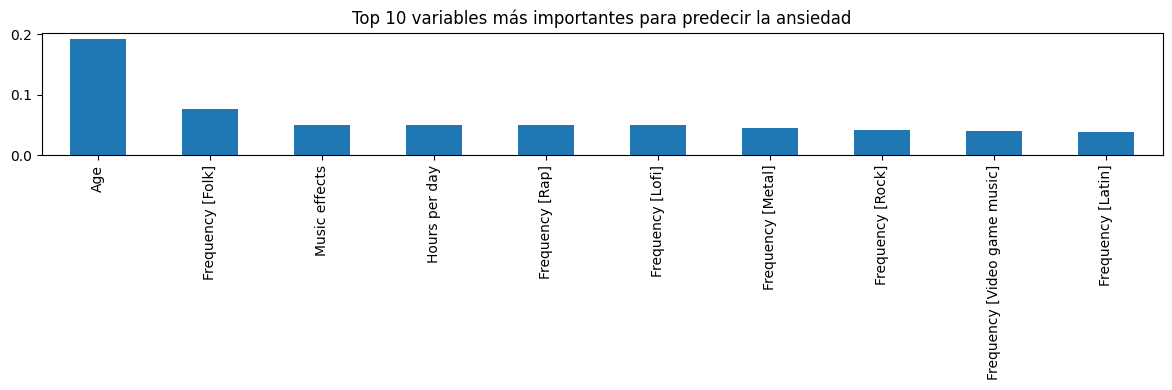

In [38]:
# FEATURE IMPORTANCE
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind="bar", figsize=(12, 4))
plt.title("Top 10 variables más importantes para predecir la ansiedad")
plt.tight_layout()
plt.show()

Las accuracy son bastante bajas tanto en train como en test, intenamos optimizar el modelo con GridSearch

In [39]:
# 1. Instanciamos el modelo base fijando el balanceo de clases para intentar evitar el overlift
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# 2. Definimos un espacio de búsqueda inteligente alrededor de tus mejores resultados
param_grid = {
    'max_depth': [3, 4],                             # Sabemos que 3 funciona bien, probamos 4 por si acaso
    'min_samples_leaf': [8, 10, 12],                 # Tu punto dulce estuvo en 10
    'min_samples_split': [16, 20, 24],               # Mantenemos la regla de pasarle el doble del leaf
    'n_estimators': [100, 150, 200],                 # Más árboles ayudan a estabilizar el test
    'max_features': ['sqrt', 'log2']                 # Cuántas columnas mira cada árbol (añade aleatoriedad)
}

# 3. Configuramos el GridSearch
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,                                            # 5 validaciones cruzadas para asegurar estabilidad
    scoring='accuracy',                              # Buscamos mejorar el accuracy global
    n_jobs=-1
)

# 4. Entrenamos
grid_search.fit(X_train, y_train)

# 5. Ver los resultados mánager
print("Mejores parámetros encontrados:", grid_search.best_params_)

Mejores parámetros encontrados: {'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 12, 'min_samples_split': 16, 'n_estimators': 100}


In [40]:
# Ahora entrena el modelo optimizado para evaluar en el test
best_gb = grid_search.best_estimator_

best_gb_pred_test = best_gb.predict(X_test)
best_gb_pred_train = best_gb.predict(X_train)

print(f"Accuracy train: {accuracy_score(y_train, best_gb_pred_train):.2f}")
print(f"Accuracy test:  {accuracy_score(y_test, best_gb_pred_test):.2f}")
print()
print(classification_report(y_test, best_gb_pred_test,
        target_names=["Ansiedad baja", "Ansiedad alta"]))

Accuracy train: 0.72
Accuracy test:  0.55

               precision    recall  f1-score   support

Ansiedad baja       0.45      0.49      0.47        51
Ansiedad alta       0.62      0.59      0.61        73

     accuracy                           0.55       124
    macro avg       0.54      0.54      0.54       124
 weighted avg       0.55      0.55      0.55       124



In [ ]:
import joblib

# Guardamos el mejor modelo encontrado por el GridSearch
best_rf_model = grid_search.best_estimator_

# Lo exportamos a un archivo .pkl
joblib.dump(best_rf_model, '../models/modelo_ansiedad_rf.pkl')

print("Modelo exportado con éxito")

Modelo exportado con éxito


## Paso 3: Desarrolla una aplicación web usando Flask

In [42]:
!pip install virtualenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 1.1 MB/s  0:00:07 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [virtualenv]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
